In [ ]:
#Import all the libraries and read two datasets into df1 and df2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score





df1 = pd.read_csv("alzheimers_disease_data.csv",low_memory=False) #use this datasets, it is able to provide a predicatable factor
df2 = pd.read_csv("alzheimers_prediction_dataset.csv")


In [3]:
#Preprocess df1 to make a labeled copy for visualization purposes
# Create a copy for labeling
df1_labeled = df1.copy()

# 1. Demographic mapping for labeling
df1_labeled['GenderLabel'] = df1['Gender'].map({0: 'Male', 1: 'Female'})
df1_labeled['EthnicityLabel'] = df1['Ethnicity'].map({
    0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'
})
df1_labeled['EducationLabel'] = df1['EducationLevel'].map({
    0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'
})

# 2. Diagnosis maping for labeling
df1_labeled['DiagnosisLabel'] = df1['Diagnosis'].map({0: 'Healthy', 1: 'Alzheimer'})

# 3. Binary Features
binary_fields = [
    'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness'
]


# Convert binary features to yes/no
for col in binary_fields:
    df1_labeled[col + '_Label'] = df1[col].map({0: 'No', 1: 'Yes'})



In [4]:
#Preprocess df2 to make a numerical version for analysis purposes

# Load the dataset
df = pd.read_csv('alzheimers_prediction_dataset.csv')  # Update the path if needed

# Identify non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()

# Exclude 'Country' from encoding
columns_to_encode = [col for col in non_numeric_columns if col != 'Country']

# Make a copy of the DataFrame
df_encoded = df.copy()

# Apply label encoding
label_encoders = {}
for col in columns_to_encode:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # Store the encoder if you need to inverse transform later

#save as df2_numeric
df2_numeric = df_encoded

# Display first few rows
print(df_encoded.head())

        Country  Age  Gender  Education Level   BMI  Physical Activity Level  \
0         Spain   90       1                1  33.0                        2   
1     Argentina   72       1                7  29.9                        2   
2  South Africa   86       0               19  22.9                        0   
3         China   53       1               17  31.2                        1   
4        Sweden   58       0                3  30.0                        0   

   Smoking Status  Alcohol Consumption  Diabetes  Hypertension  ...  \
0               2                    1         0             0  ...   
1               1                    0         0             0  ...   
2               0                    1         0             1  ...   
3               2                    2         1             0  ...   
4               1                    0         1             0  ...   

   Dietary Habits  Air Pollution Exposure  Employment Status  Marital Status  \
0           

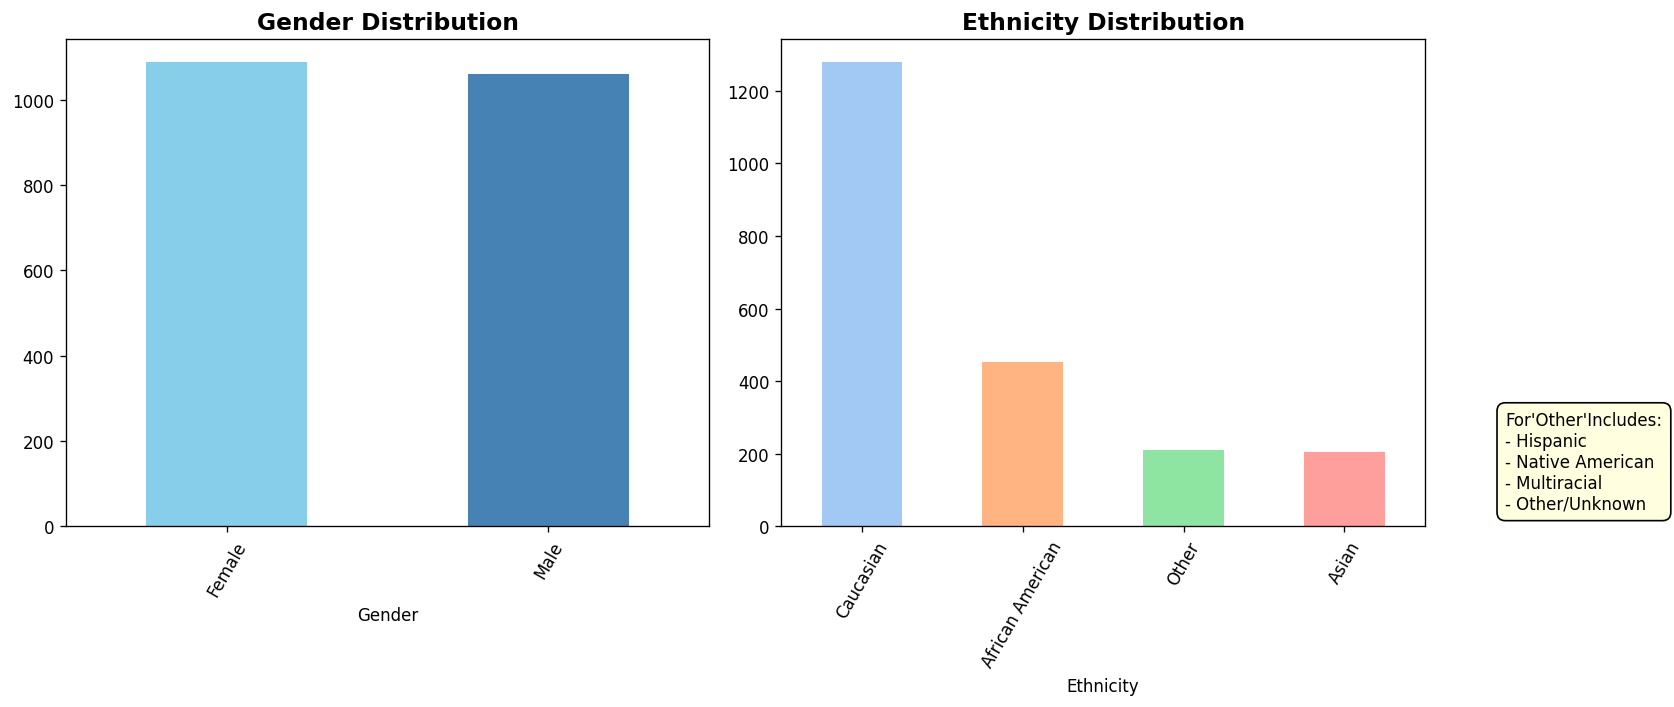

In [5]:
#Figure 1: Gender distribution and Ethnicity distribution for df1
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

# Gender barplot
df1_labeled['GenderLabel'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'steelblue'])
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel("Gender")

# Ethnicity barplot
df1_labeled['EthnicityLabel'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette("pastel"))
axes[1].set_title('Ethnicity Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel("Ethnicity")

# Add comments to the side
axes[1].text(
    x=4, y=50, 
    s="For'Other'Includes:\n- Hispanic\n- Native American\n- Multiracial\n- Other/Unknown", 
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='Black', boxstyle='round,pad=0.5')
)

axes[0].tick_params(axis='x', rotation=60)
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


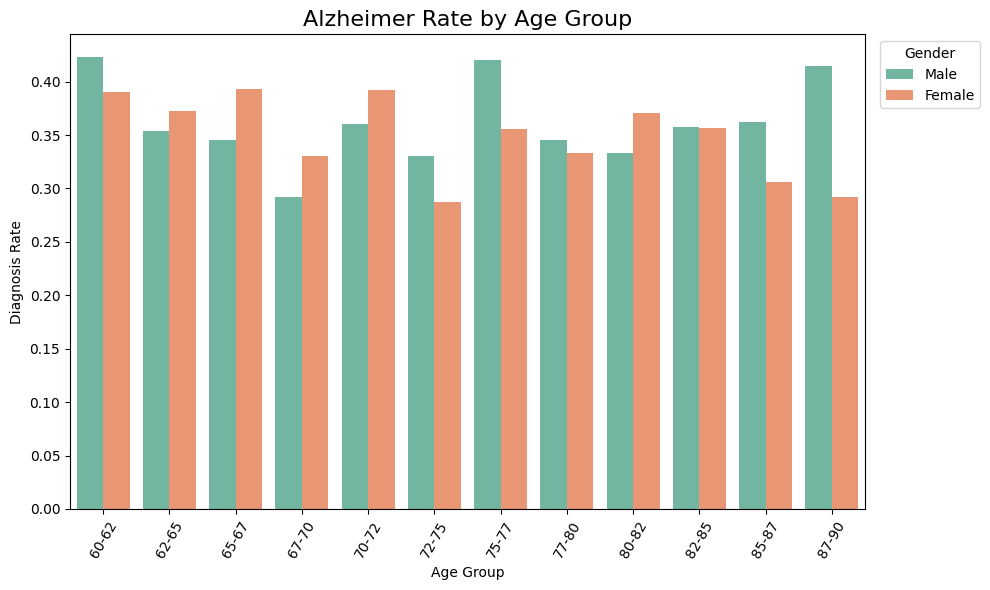

In [6]:
# Figure 2: Alzheimer Rate by Age Group with color coded gender for df1
bins = [60, 62, 65, 67, 70, 72, 75, 77, 80, 82, 85, 87, 90]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df1_labeled['AgeGroup'] = pd.cut(df1_labeled['Age'], bins=bins, labels=labels, right=False)

# Separate into different groups 
age_diag = df1_labeled.groupby('AgeGroup', observed=False)['Diagnosis'].mean().reset_index()

#Plot the figure
plt.figure(figsize=(10, 6))
sns.barplot(data=df1_labeled,
            x='AgeGroup', y='Diagnosis',
            hue='GenderLabel', palette='Set2',errorbar=('ci', False))
plt.title("Alzheimer Rate by Age Group", fontsize=16)
plt.ylabel("Diagnosis Rate")
plt.xlabel("Age Group")
plt.legend(title='Gender', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


In [ ]:
# Figure 3: Heatmap(Large expend for check) for df1
df = df1.drop(columns=["DoctorInCharge"], errors='ignore')

# Calculates correlation
corr = df.corr(numeric_only=True)

# Plotting heatmap between each feature that contains numeric data
plt.figure(figsize=(30, 20))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


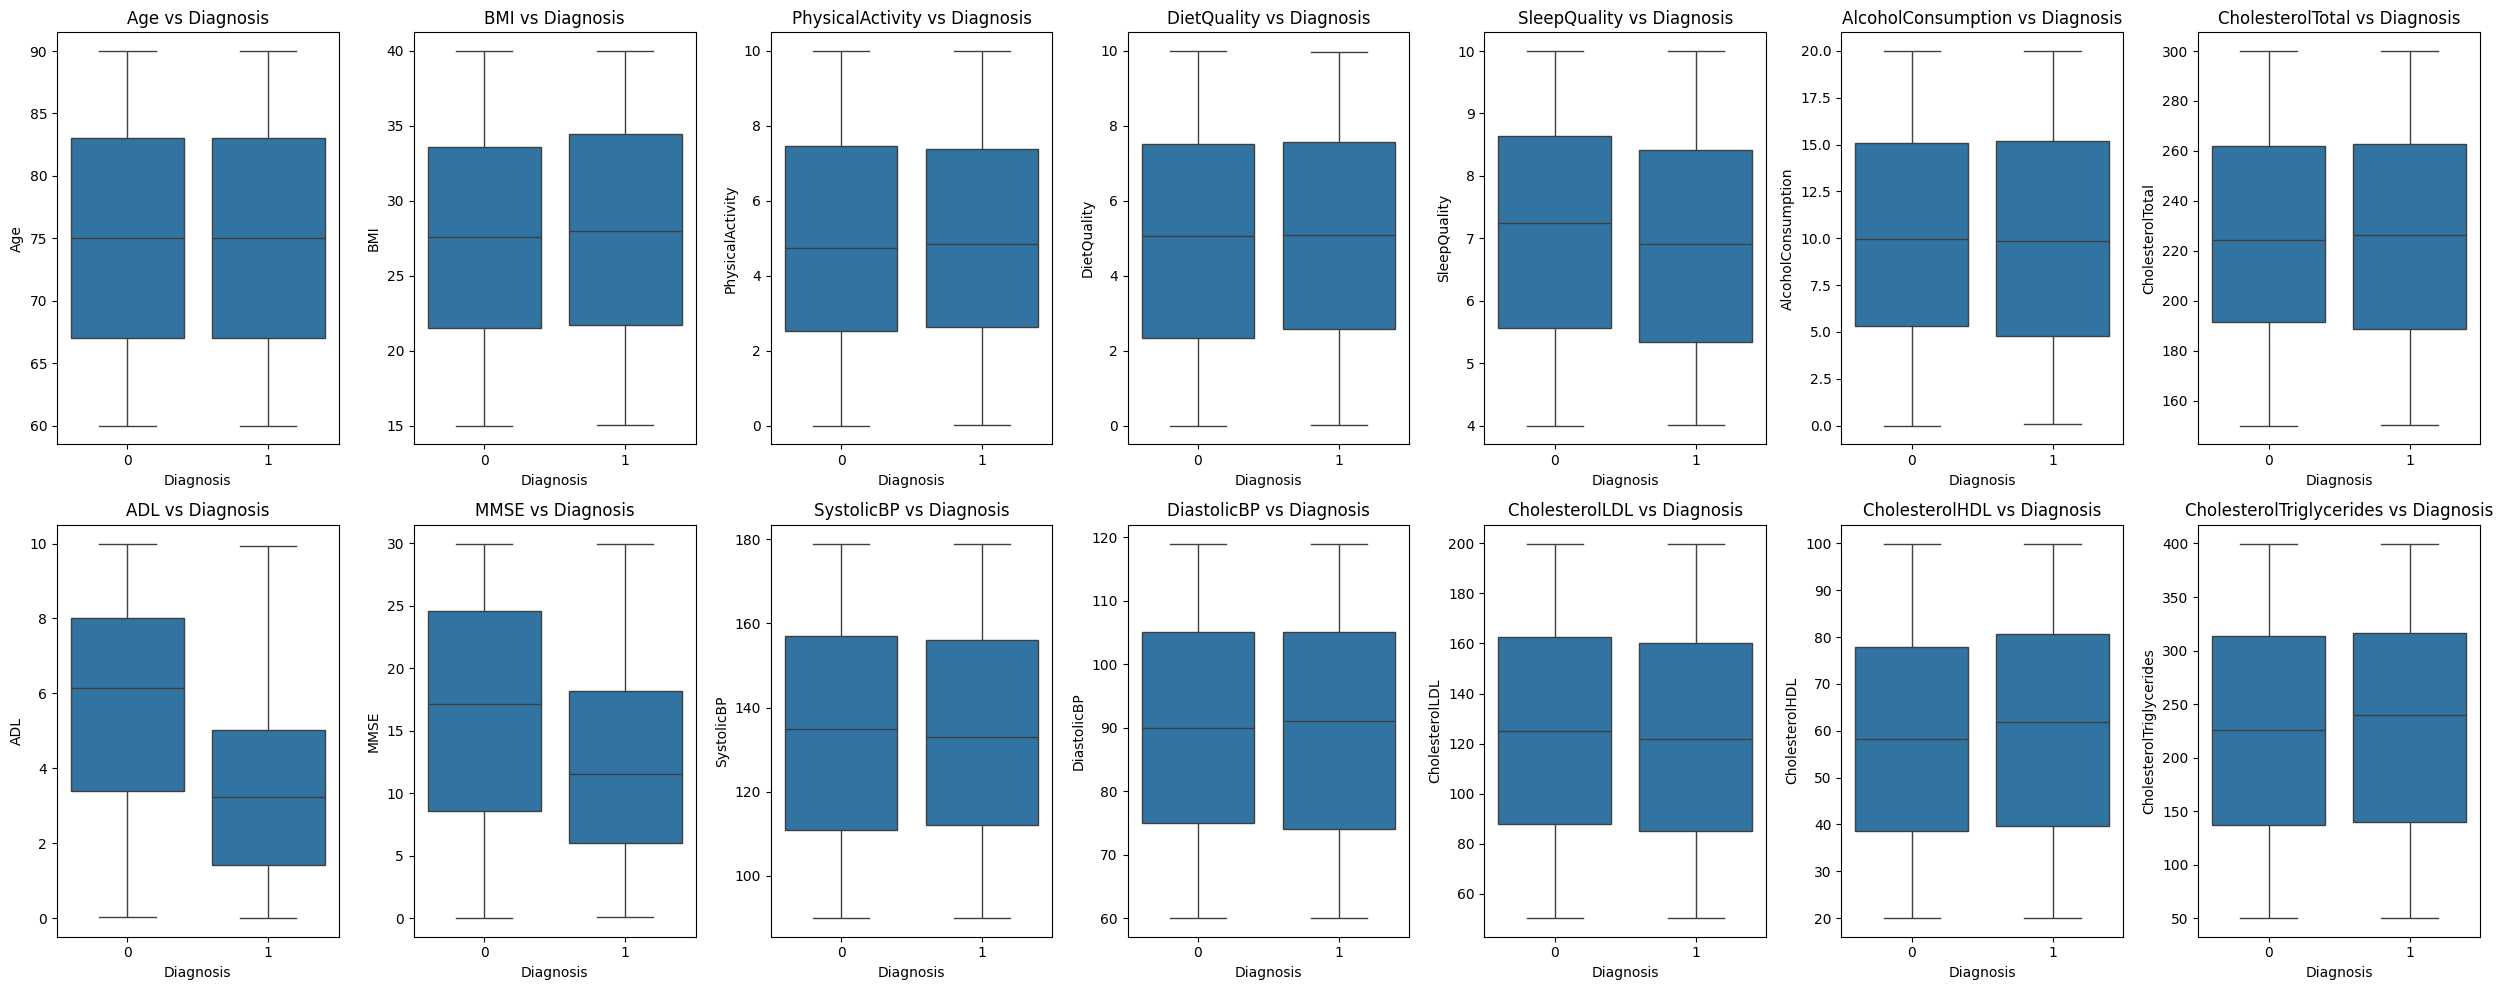

In [8]:
# Figure 4: Boxplot comparing features that are not binary with diagnosis for df1
# Select all features that are not binary to compare against 'Diagnosis'
features_to_plot = [
    'Age', 'BMI', 'PhysicalActivity', 'DietQuality',
    'SleepQuality', 'AlcoholConsumption', 'CholesterolTotal', 'ADL', 'MMSE',
    'SystolicBP', 'DiastolicBP', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides'
]

# Set up the subplot grid: 2 rows x 7 columns
fig, axes = plt.subplots(2, 7, figsize=(25, 10))
axes = axes.flatten()

# Plot each feature as a boxplot grouped by Diagnosis
for i, feature in enumerate(features_to_plot):
    sns.boxplot(x='Diagnosis', y=feature, data=df1, ax=axes[i])
    axes[i].set_title(f"{feature} vs Diagnosis")
    axes[i].set_xlabel("Diagnosis")
    axes[i].set_ylabel(feature)

# Adjust spacing
plt.tight_layout()
plt.show()


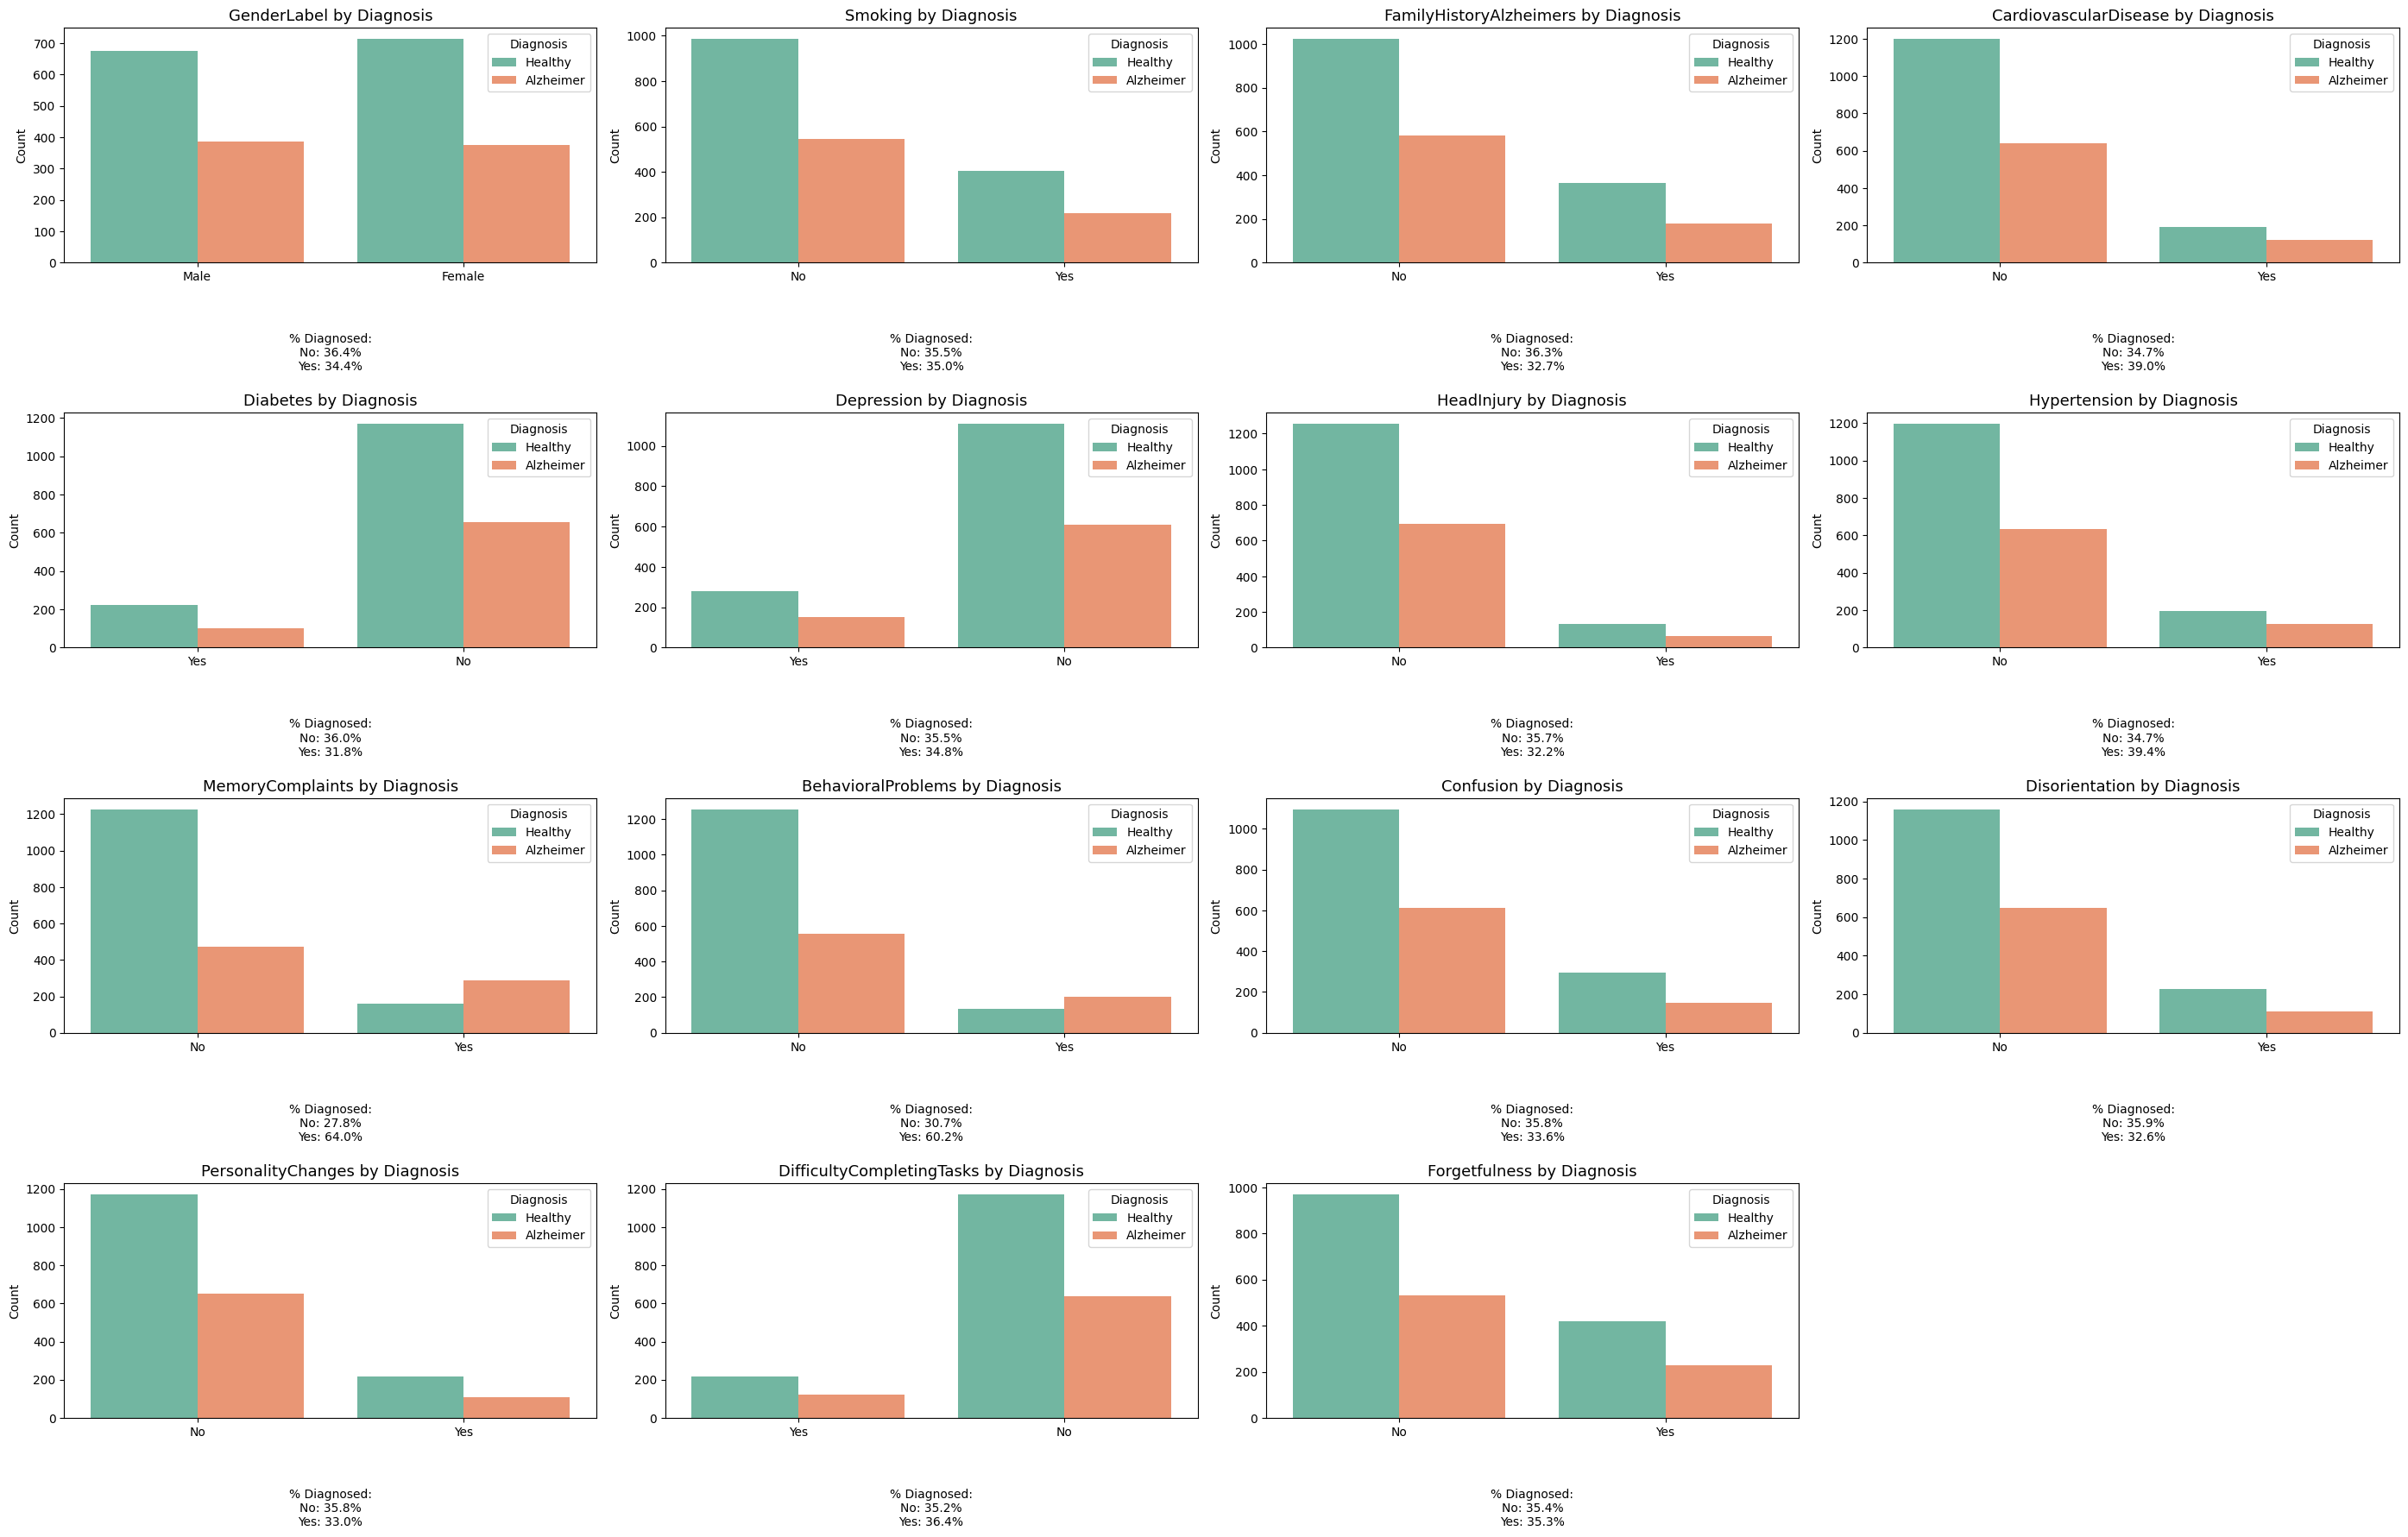

In [9]:
# Figure 5: Barplot comparing binary feature with diagnosis for df1
df = df1_labeled.copy()

# Binary features labeled with descriptions
binary_features = [
    'GenderLabel', 'Smoking_Label', 'FamilyHistoryAlzheimers_Label', 'CardiovascularDisease_Label',
    'Diabetes_Label', 'Depression_Label', 'HeadInjury_Label', 'Hypertension_Label',
    'MemoryComplaints_Label', 'BehavioralProblems_Label', 'Confusion_Label', 'Disorientation_Label',
    'PersonalityChanges_Label', 'DifficultyCompletingTasks_Label', 'Forgetfulness_Label'
]

# Binary features with original names
original_features = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

# Create a 4x4 grid with the last cell being empty
fig, axes = plt.subplots(4, 4, figsize=(28, 18))
axes = axes.flatten()

# Plot each feature as barplot 
for i, (label_feat, raw_feat) in enumerate(zip(binary_features, original_features)):
    # Calculate percentage of diagnosed for each feature
    total = df[raw_feat].value_counts()
    diagnosed = df[df['Diagnosis'] == 1][raw_feat].value_counts()
    percent_0 = (diagnosed.get(0, 0) / total.get(0, 1)) * 100
    percent_1 = (diagnosed.get(1, 0) / total.get(1, 1)) * 100

    # Using seaborn to plot the barplot
    sns.countplot(data=df, x=label_feat, hue='DiagnosisLabel', ax=axes[i], palette='Set2')
    axes[i].set_title(f"{label_feat.replace('_Label', '')} by Diagnosis", fontsize=13)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Diagnosis")

    # Annotate each grid with percentages calculated
    annotation = f"% Diagnosed:\nNo: {percent_0:.1f}%\nYes: {percent_1:.1f}%"
    axes[i].text(0.5, -0.3, annotation, transform=axes[i].transAxes,
                 ha='center', va='top', fontsize=10)

# Hide the last cell
axes[-1].axis('off')

plt.tight_layout()
plt.show()


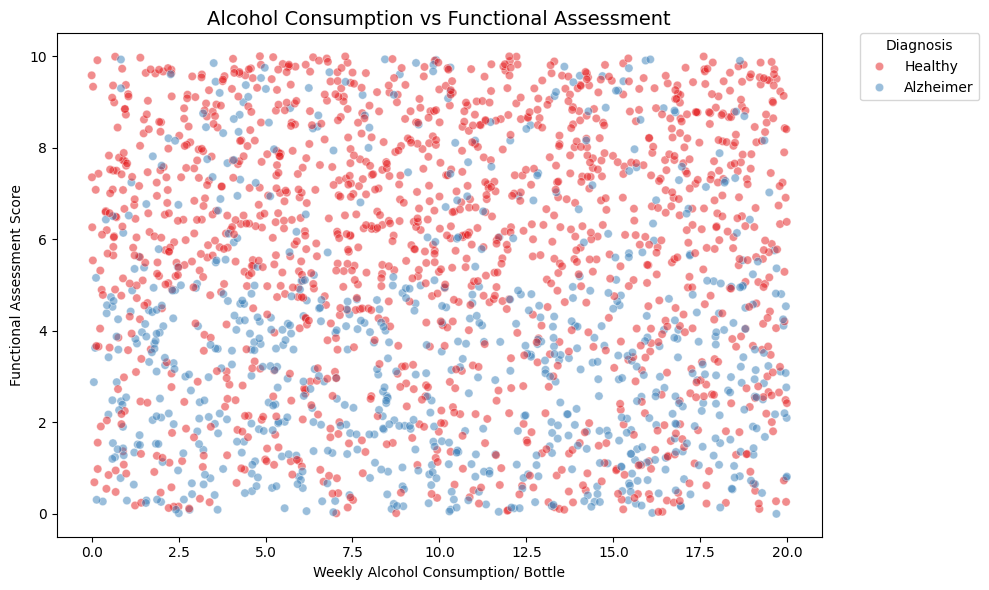

In [10]:
#Figure 6：Alcohol Consumption vs Functional Assessment scatterplot for df1
#Compares healthy and alzheimer older adults across alcohol consumption and functional assessment
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1_labeled, x='AlcoholConsumption', y='FunctionalAssessment', 
                hue='DiagnosisLabel', alpha=0.5, palette='Set1')

#Label the figure
plt.title("Alcohol Consumption vs Functional Assessment", fontsize=14)
plt.xlabel("Weekly Alcohol Consumption/ Bottle")
plt.ylabel("Functional Assessment Score")

# Lable on the upper left
plt.legend(title="Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()



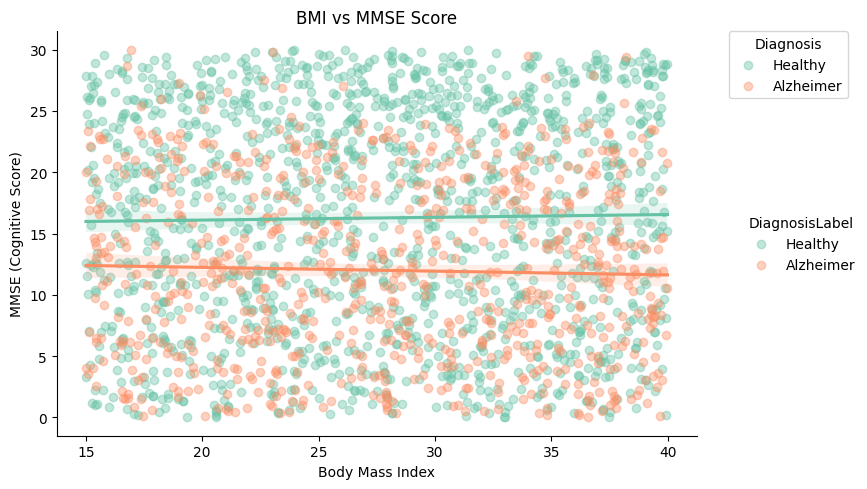

In [11]:
# Figure 7: BMI vs MMSE Score scatterplot for df1
# BMI is the body mass index, MMSE is mental state examination score, lower score represent cognitive impairment
sns.lmplot(data=df1_labeled, x='BMI', y='MMSE', hue='DiagnosisLabel', aspect=1.5, 
           scatter_kws={'alpha': 0.4}, palette='Set2')
plt.legend(title="Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("BMI vs MMSE Score")
plt.xlabel("Body Mass Index")
plt.ylabel("MMSE (Cognitive Score)")
plt.tight_layout()


                         PC1       PC2
BMI                 0.145336 -0.249476
AlcoholConsumption  0.268559  0.661108
PhysicalActivity    0.220709  0.611552
DietQuality         0.712111 -0.105018
SleepQuality        0.592400 -0.340107


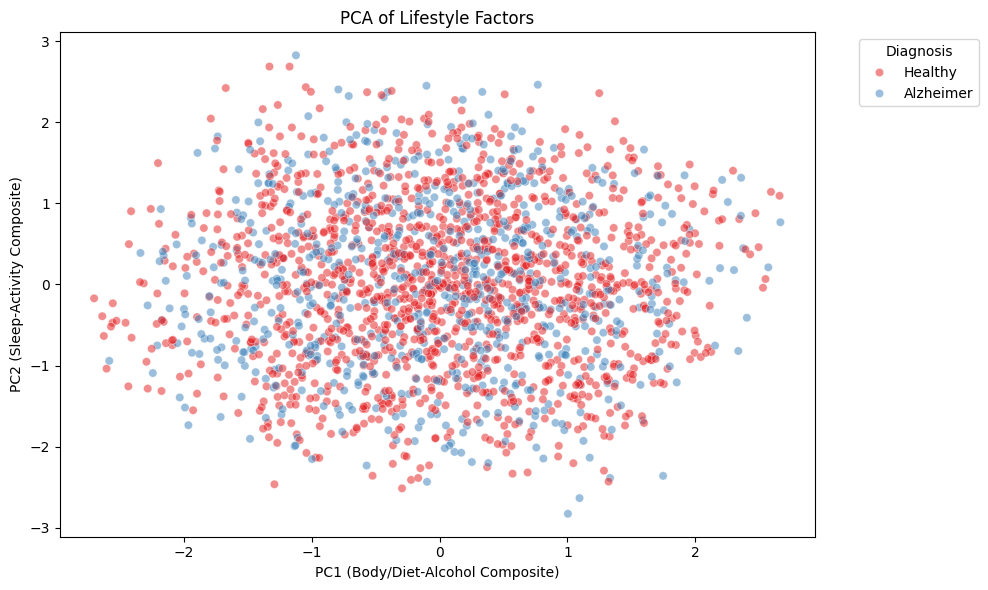

In [12]:
#Figure 8：PCA of Lifestyle factors scatterplot for df1
#The 5 lifestyle-related variables were downscaled to 2 composite score dimensions (PC1 and PC2)
#  Feature selection
features = ['BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']
X = df1[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

# PCA 
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1', 'PC2'])
print(loadings)

diagnosis = df1_labeled.loc[X.index, 'DiagnosisLabel']
plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=diagnosis, alpha=0.5, palette='Set1')
plt.title("PCA of Lifestyle Factors")
plt.xlabel("PC1 (Body/Diet-Alcohol Composite)")
plt.ylabel("PC2 (Sleep-Activity Composite)")
plt.legend(title="Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

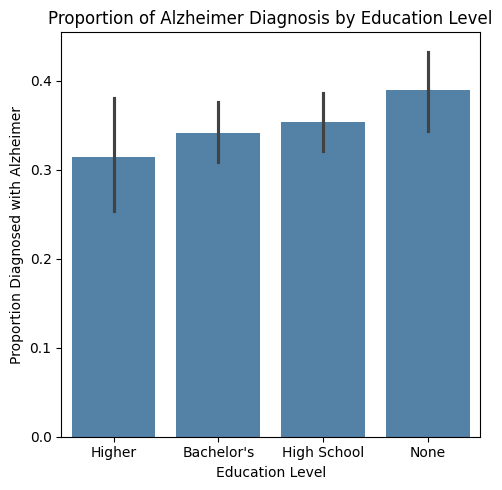

In [13]:
#Figure 9: Comparison of education level vs Alzheimer Diagnosis barplot for df1
#Changing the order of arrangement
df1_labeled['EducationLabel'] = pd.Categorical(
    df1_labeled['EducationLabel'],
    categories=["Higher", "Bachelor's", "High School", "None"],
    ordered=True
)

plt.figure(figsize=(5, 5))
sns.barplot(
    data=df1_labeled,
    x='EducationLabel', y='Diagnosis',
    estimator=np.mean,
    color='steelblue' 
)
plt.title("Proportion of Alzheimer Diagnosis by Education Level")
plt.ylabel("Proportion Diagnosed with Alzheimer")
plt.xlabel("Education Level")
plt.tight_layout()
plt.show()


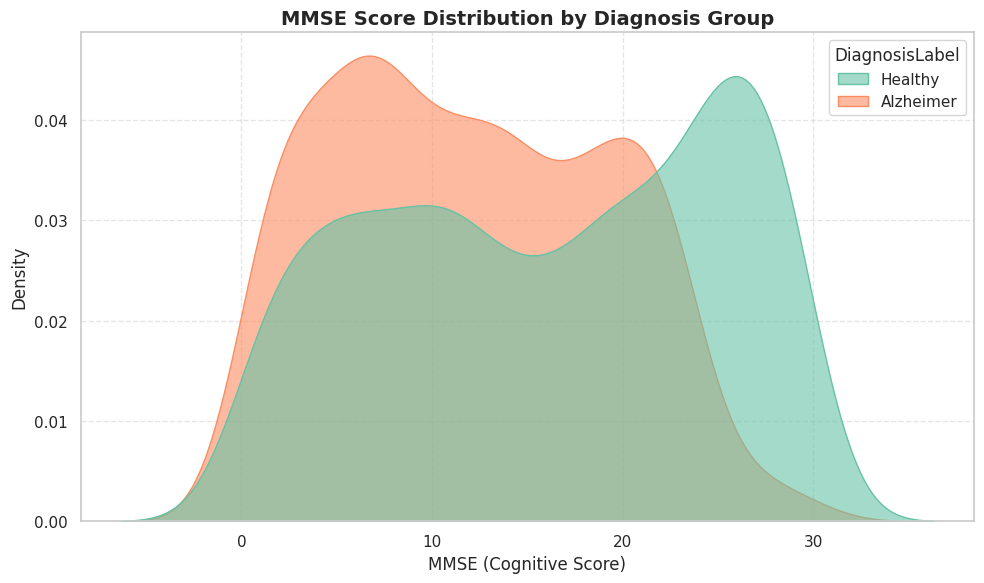

In [14]:
#Figure 10: MMSE Score distribution by diagnosis group for df1
#Significant Distributional Differences in MMSE Scores Between Healthy and Alzheimer's Disease Groups
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.kdeplot(data=df1_labeled, x='MMSE', hue='DiagnosisLabel',
            fill=True, common_norm=False, palette='Set2', alpha=0.6)

plt.title("MMSE Score Distribution by Diagnosis Group", fontsize=14, fontweight='bold')
plt.xlabel("MMSE (Cognitive Score)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


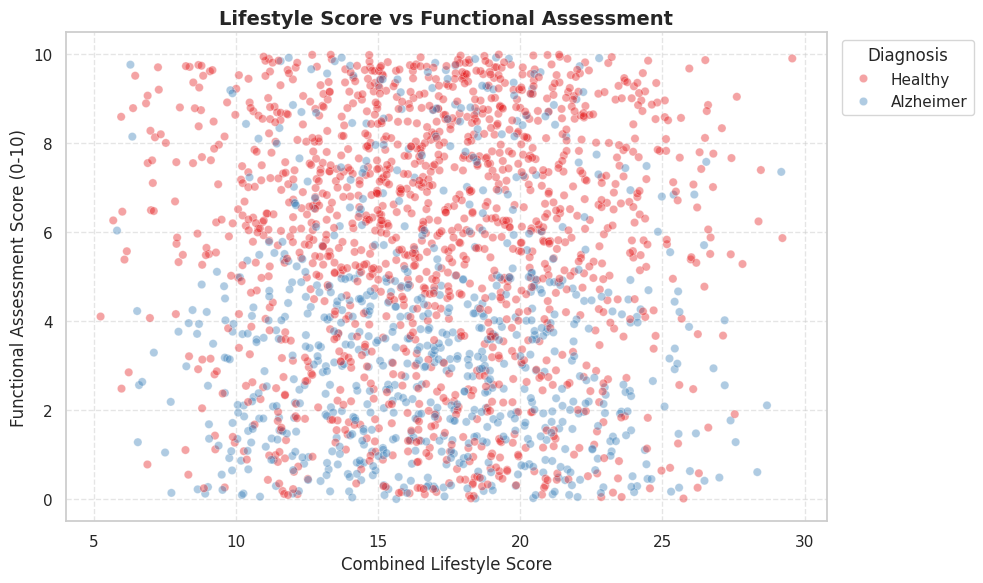

In [15]:
#Figure 11: Lifestyle score vs functional assessment for df1
df1_labeled['LifestyleScore'] = df1[['SleepQuality', 'DietQuality', 'PhysicalActivity']].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(data=df1_labeled,
                x='LifestyleScore',
                y='FunctionalAssessment',
                hue='DiagnosisLabel',
                alpha=0.4,
                palette='Set1')

plt.title("Lifestyle Score vs Functional Assessment", fontsize=14, fontweight='bold')
plt.xlabel("Combined Lifestyle Score", fontsize=12)
plt.ylabel("Functional Assessment Score (0-10)", fontsize=12)
plt.legend(title="Diagnosis", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


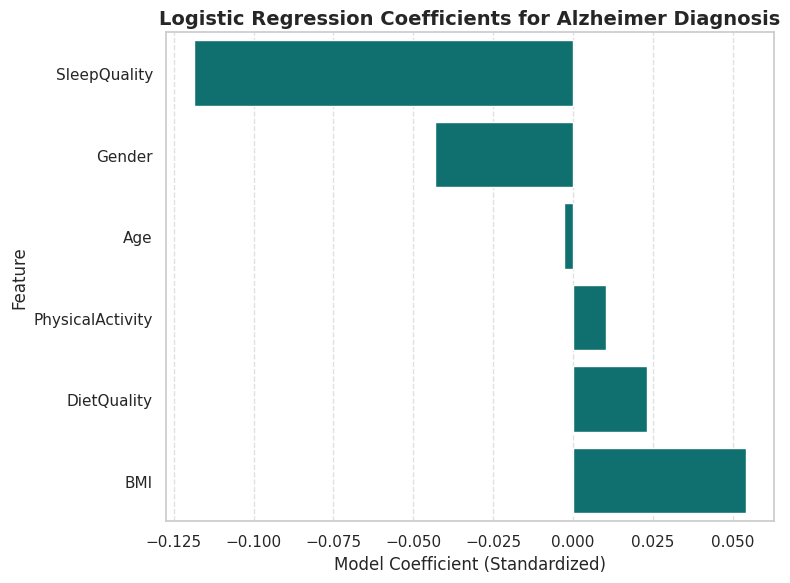

In [16]:
#Figure 12. Standardized logistic regression coefficients for predicting Alzheimer’s diagnosis. Negative coefficients (e.g., Sleep Quality and Gender) indicate a protective effect, while positive coefficients (e.g., BMI and Diet Quality) suggest increased risk. Sleep quality emerged as the most influential predictor in this model.
features = ['Age', 'Gender', 'BMI', 'PhysicalActivity', 'SleepQuality', 'DietQuality']
X = df1[features].dropna()
y = df1.loc[X.index, 'Diagnosis']
X_scaled = StandardScaler().fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

importance_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
importance_df.sort_values(by='Coefficient', inplace=True)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=importance_df,
            x='Coefficient',
            y='Feature',
            color='teal')

plt.title("Logistic Regression Coefficients for Alzheimer Diagnosis", fontsize=14, fontweight='bold')
plt.xlabel("Model Coefficient (Standardized)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


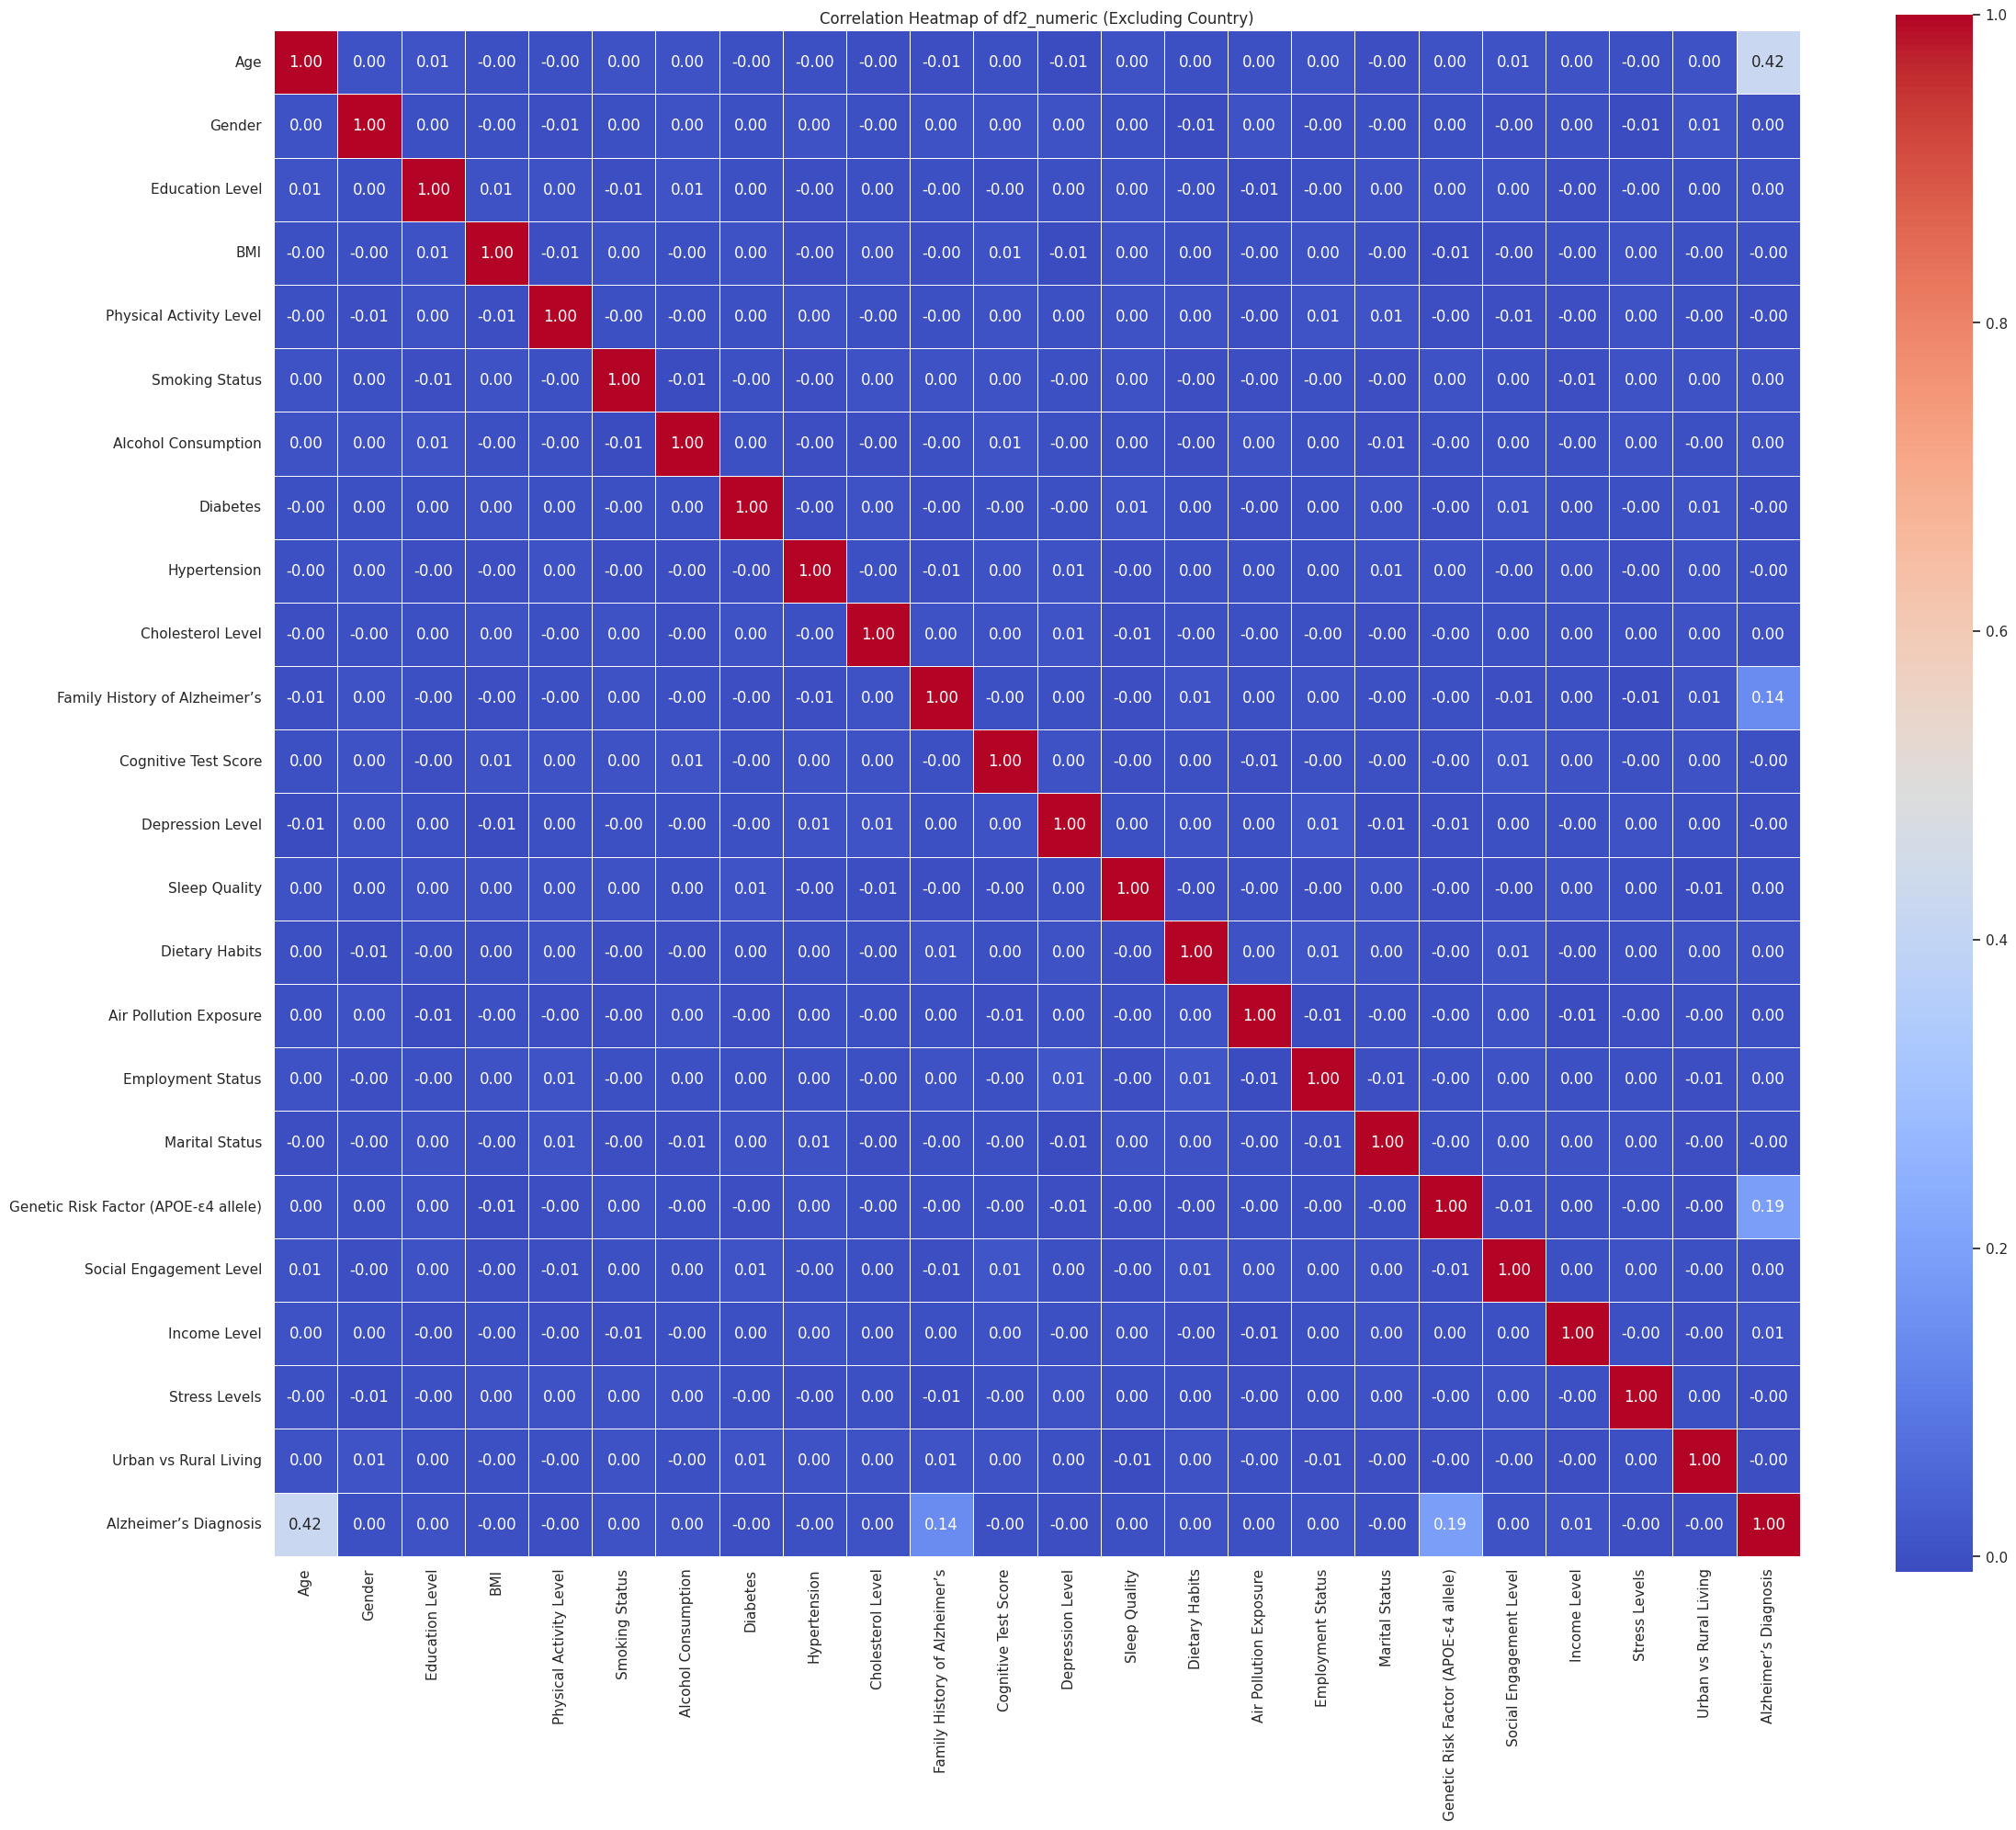

In [17]:
#Figure 13. Heatmap for df2

# Compute the correlation matrix
corr_matrix = df2_numeric.drop(columns=['Country']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Show correlation values
            fmt='.2f',           # Format as float with 2 decimals
            cmap='coolwarm',     # Color map
            square=True, 
            linewidths=0.5)

# Add title and layout
plt.title('Correlation Heatmap of df2_numeric (Excluding Country)')
plt.tight_layout()
plt.show()




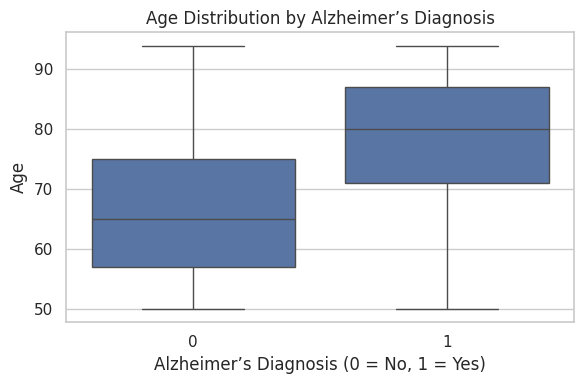

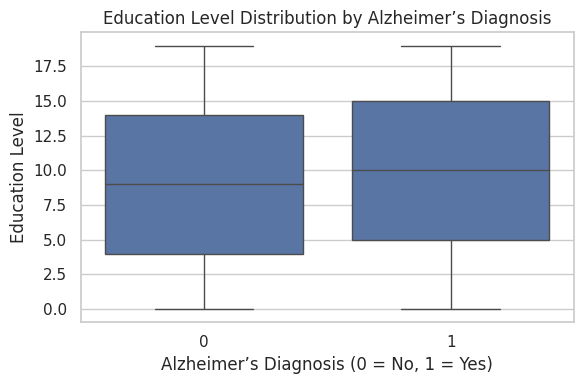

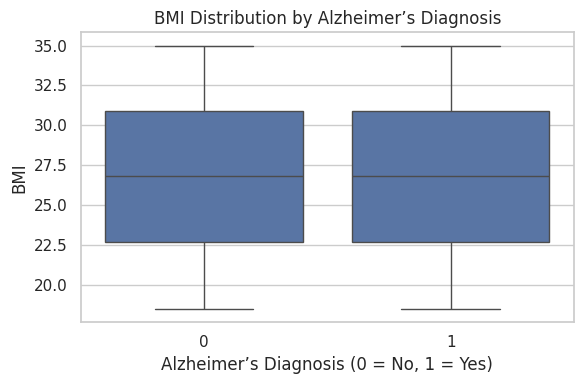

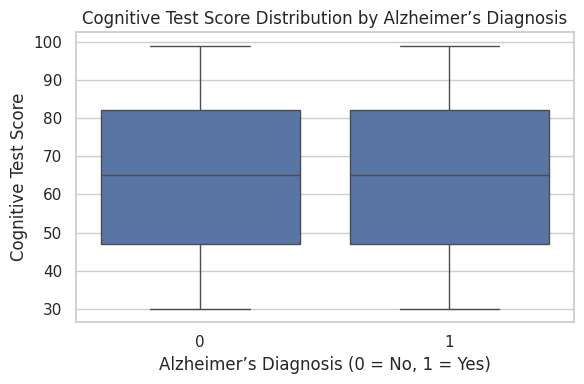

In [18]:
#Figure 14. Boxplot for comparing numerical features against Alzheimer's diagnosis for df2

# List of numeric features
numeric_features = ['Age', 'Education Level', 'BMI', 'Cognitive Test Score']

# Loop through each numeric feature
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df2_numeric['Alzheimer’s Diagnosis'], y=df2_numeric[feature])
    plt.title(f'{feature} Distribution by Alzheimer’s Diagnosis')
    plt.xlabel('Alzheimer’s Diagnosis (0 = No, 1 = Yes)')
    plt.ylabel(feature)
    
    
    plt.tight_layout()
    plt.show()



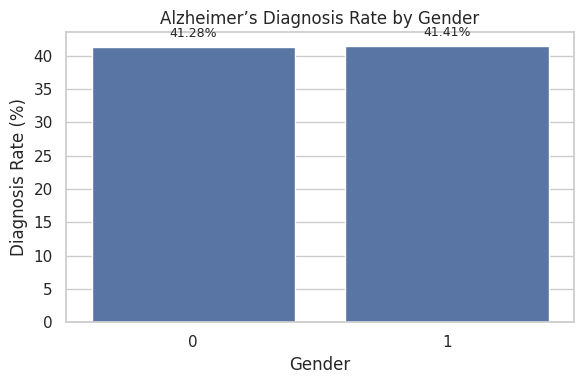

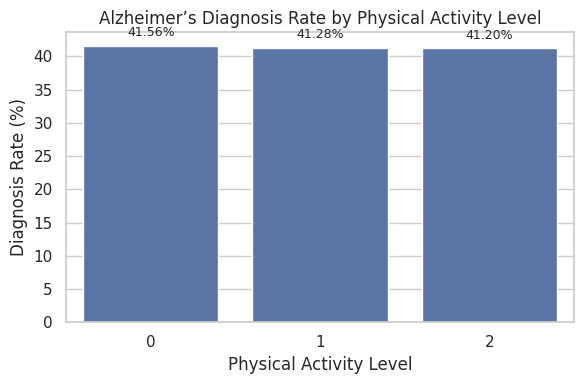

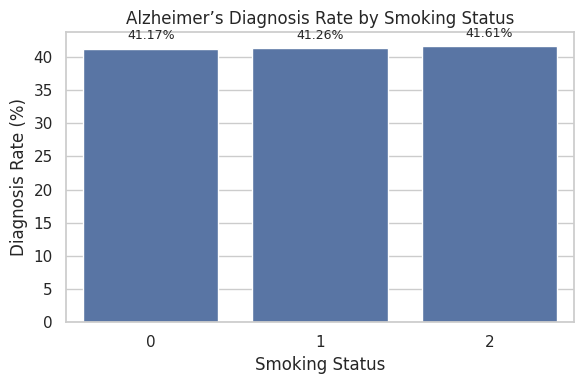

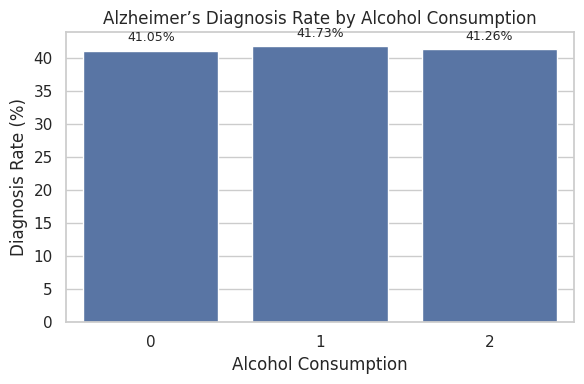

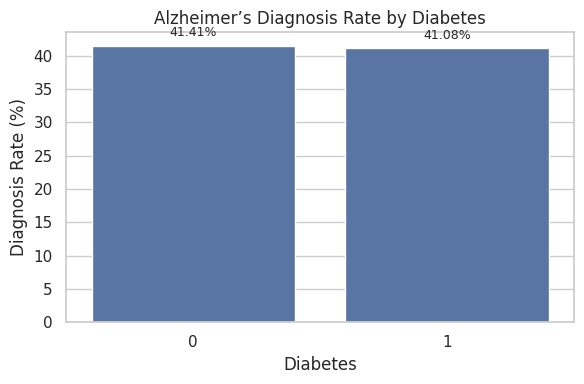

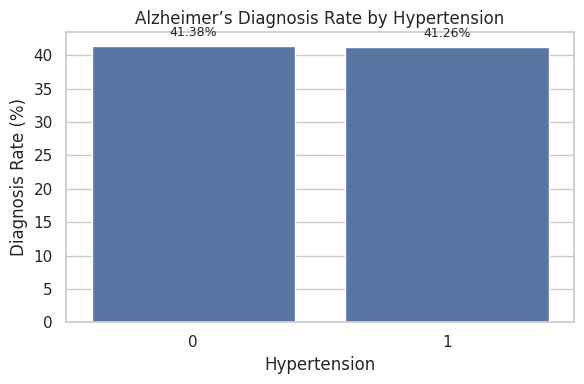

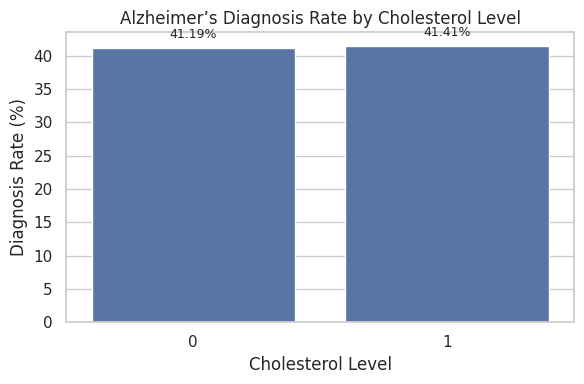

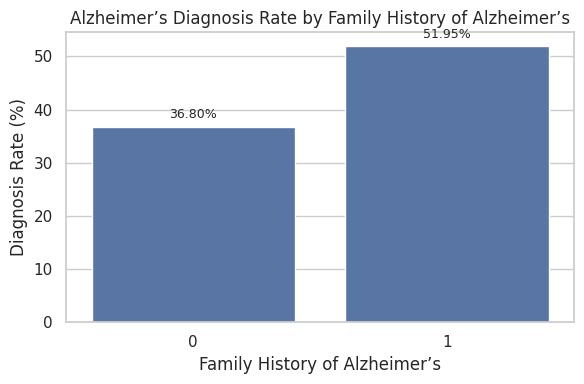

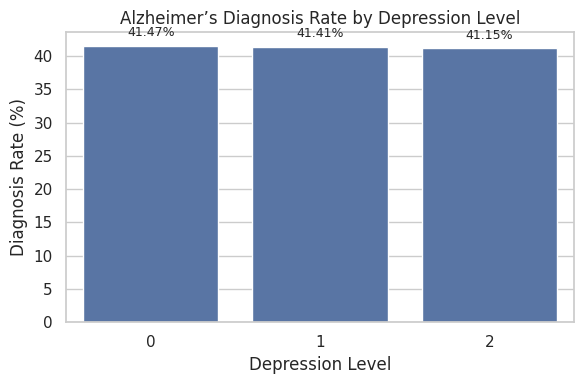

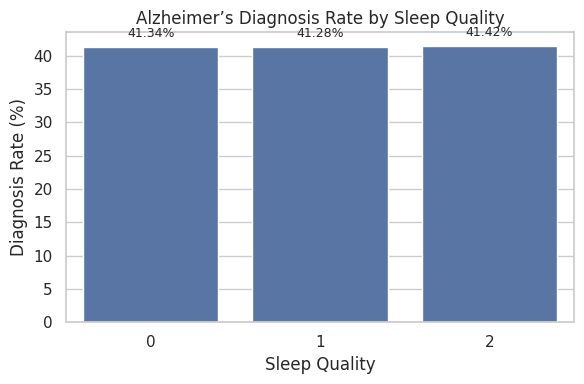

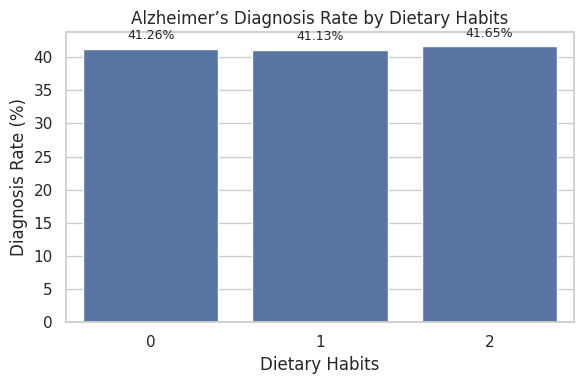

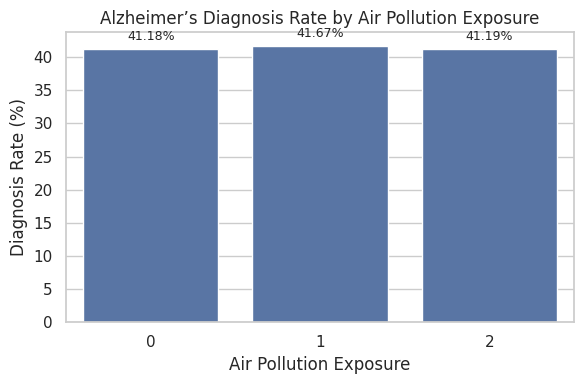

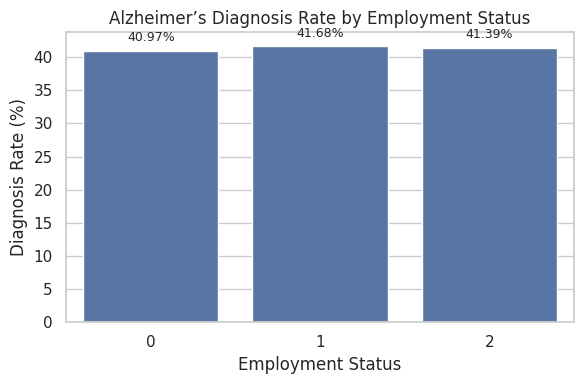

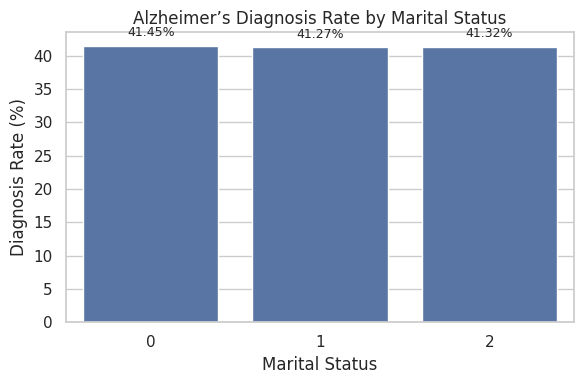

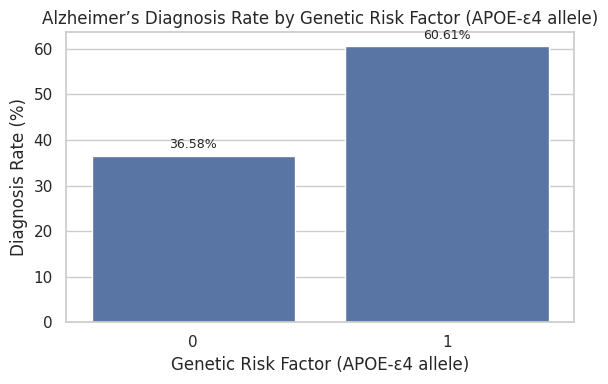

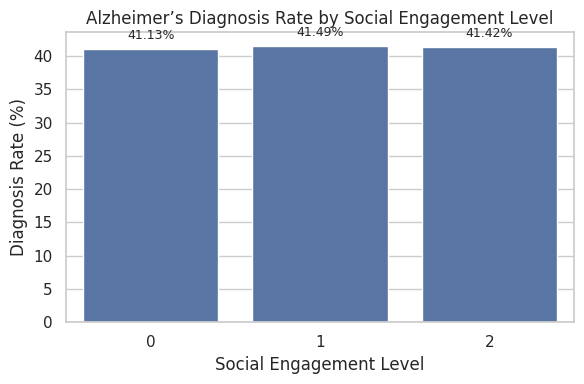

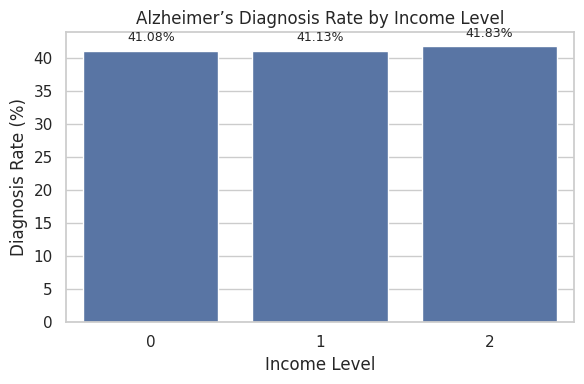

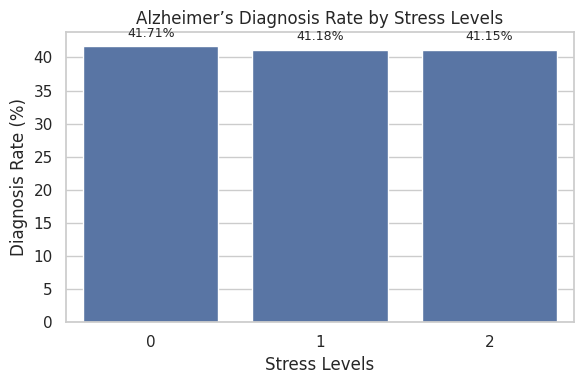

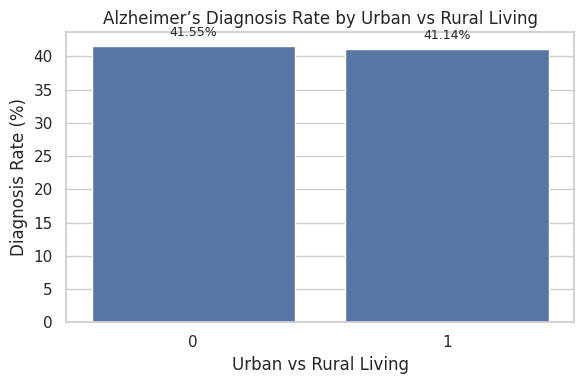

In [19]:
#Figure 15. Barplot for comparing categorical features against Alzheimer's diagnosis for df2

# Categorical and binary features (excluding numeric and Country)
categorical_and_binary_features = [
    col for col in df2_numeric.columns
    if col not in ['Age', 'Education Level', 'BMI', 'Alzheimer’s Diagnosis', 'Country', 'Cognitive Test Score']
]

# Loop through each feature
for feature in categorical_and_binary_features:
    plt.figure(figsize=(6, 4))

    # Calculate diagnosis rate (percentage)
    diagnosis_rate = df2_numeric.groupby(feature)['Alzheimer’s Diagnosis'].mean() * 100

    # Create barplot
    sns.barplot(x=diagnosis_rate.index, y=diagnosis_rate.values)
    plt.title(f'Alzheimer’s Diagnosis Rate by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Diagnosis Rate (%)')

    # Annotate each bar
    for i, value in enumerate(diagnosis_rate.values):
        plt.text(i, value + 1, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76      8719
           1       0.67      0.60      0.63      6138

    accuracy                           0.71     14857
   macro avg       0.70      0.70      0.70     14857
weighted avg       0.71      0.71      0.71     14857

Confusion Matrix:
[[6902 1817]
 [2455 3683]]


/tmp/ipykernel_3713178/600422838.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(top_n), x='AbsCoefficient', y='Feature', palette='viridis')


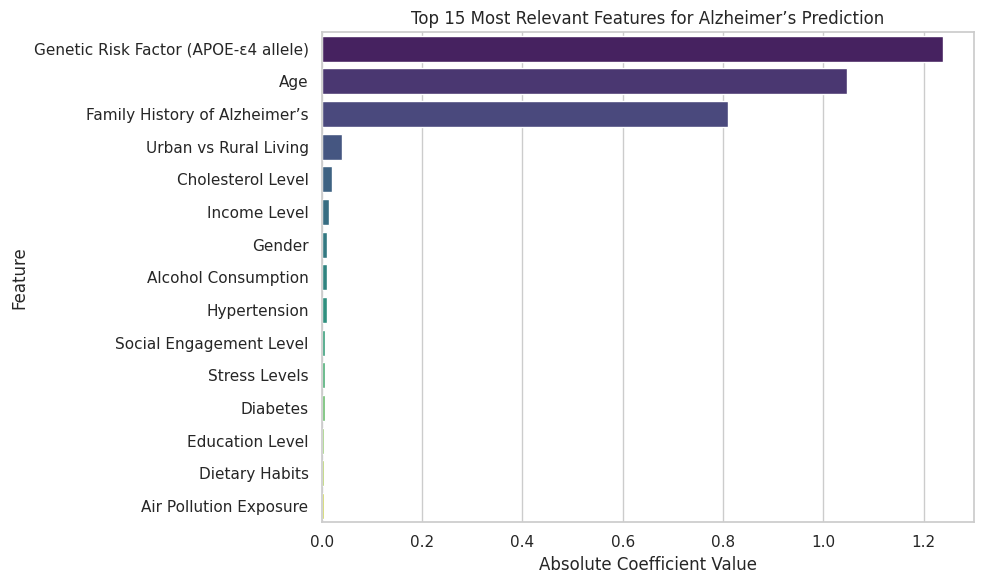

In [20]:
#Training logistic regression model using df2

# Define features and target
X = df2_numeric.drop(columns=['Alzheimer’s Diagnosis', 'Country'])  # Drop target and Country
y = df2_numeric['Alzheimer’s Diagnosis']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_cols = ['Age', 'Education Level', 'BMI']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Get feature names and coefficients
feature_names = X.columns
coefficients = log_reg.coef_[0]

# Create a DataFrame for easy sorting and plotting
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values(by='AbsCoefficient', ascending=False)

# Plot the top N features
top_n = 15
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(top_n), x='AbsCoefficient', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Most Relevant Features for Alzheimer’s Prediction')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76      8719
           1       0.66      0.64      0.65      6138

    accuracy                           0.72     14857
   macro avg       0.71      0.71      0.71     14857
weighted avg       0.72      0.72      0.72     14857

Confusion Matrix:
 [[6745 1974]
 [2224 3914]]


/tmp/ipykernel_3713178/259026223.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', palette='crest')


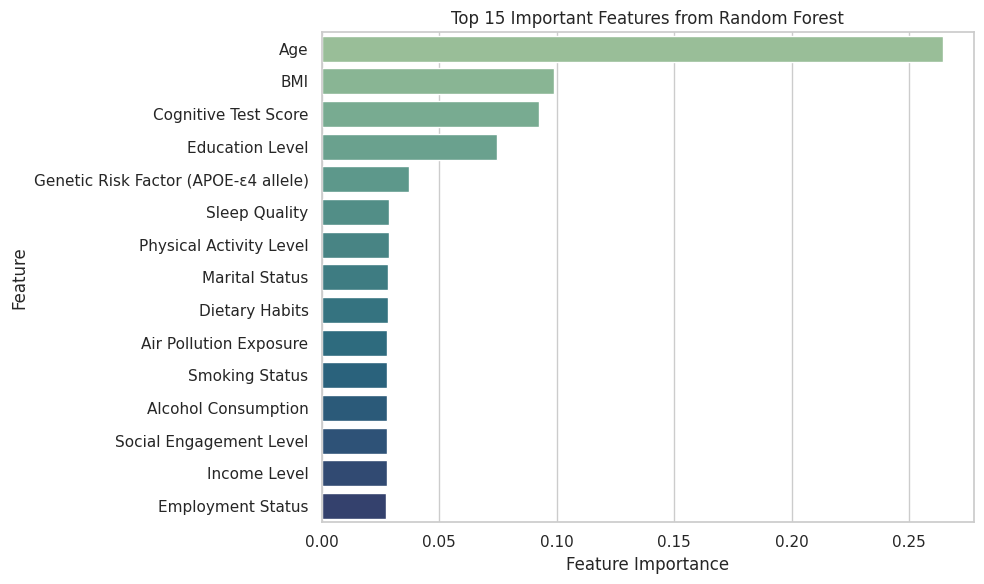

In [21]:
#Training random forest model for df2

# Define features and target
X = df2_numeric.drop(columns=['Alzheimer’s Diagnosis', 'Country'])
y = df2_numeric['Alzheimer’s Diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_cols = ['Age', 'Education Level', 'BMI']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top N Features
top_n = 15
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', palette='crest')
plt.title(f'Top {top_n} Important Features from Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness'],
      dtype='object')
Confusion Matrix:
[[272   5]
 [ 27 126]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.96      0.82      0.89       153

    accuracy                           0.93       430
   macro avg       0.94      0.90      0.92       430
weighted avg       0.93      0.93    

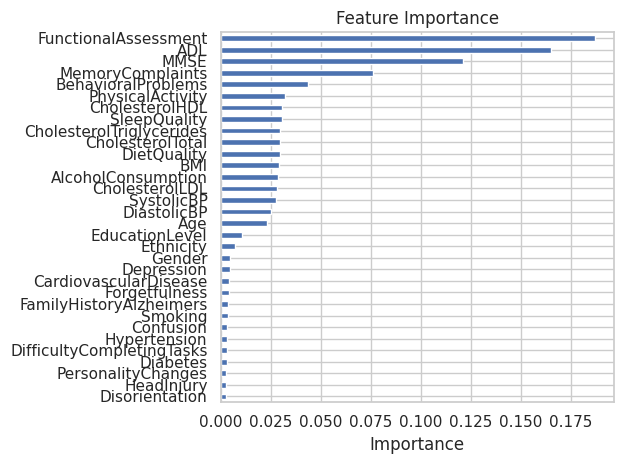

In [22]:
#Training a Random Forest Model for df1

# Step 1: Define features and target
X = df1.drop(columns=['Diagnosis', 'PatientID', 'DoctorInCharge'], errors='ignore') # drops the columns that are not a feature
y = df1['Diagnosis']

# Optional: one-hot encode categorical variables if needed
X = pd.get_dummies(X, drop_first=True)

# Step 2: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # for ROC-AUC

# Step 5: Evaluate the model
print(X.columns)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")


# Step 6: Plot Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


/common/home/yx365/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[246  31]
 [ 43 110]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       277
           1       0.78      0.72      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430

ROC-AUC Score: 0.89


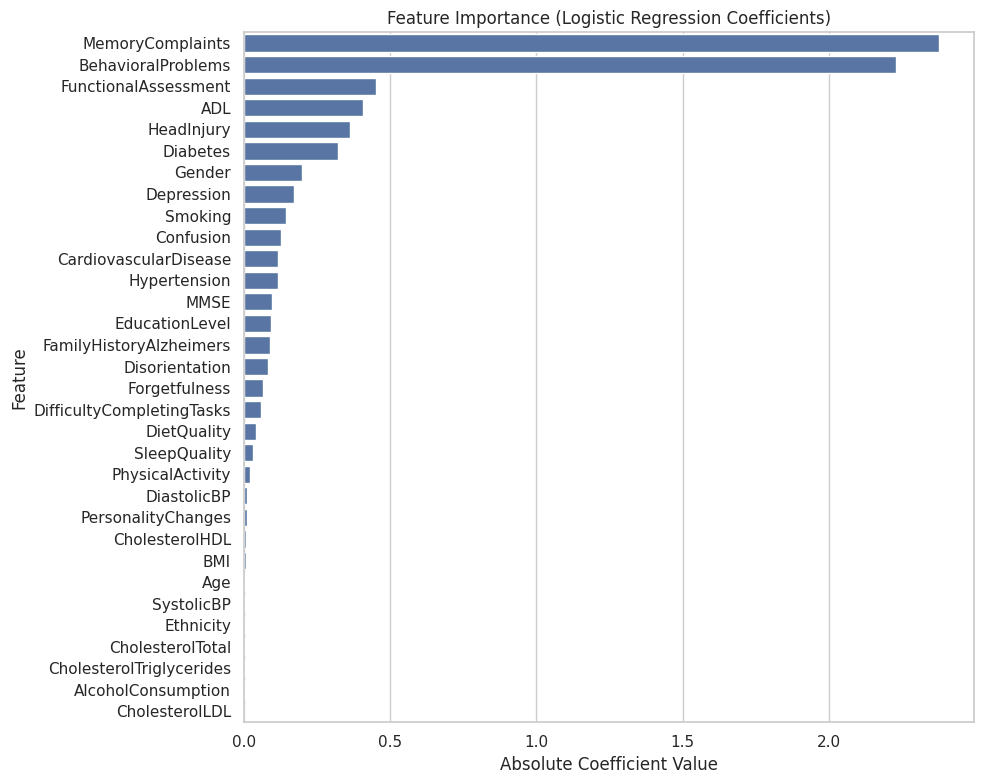

In [23]:
#Training a Logistic Regression Model for df1

# Step 3: Remove PatientID and select numeric features
if 'PatientID' in df1.columns:
    df1 = df1.drop(columns=['PatientID'])

numeric_df1 = df1.select_dtypes(include='number')

# Step 4: Define features and target
X = numeric_df1.drop(columns=['Diagnosis'], errors='ignore')
y = numeric_df1['Diagnosis']

# Step 5: Handle missing data
X = X.dropna()
y = y.loc[X.index]

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 7: Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 8: Evaluate model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

# Step 9: Plot feature importance
importance = pd.Series(model.coef_[0], index=X.columns).abs().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



#Excessive differences in standard deviation of feature data